# Credit Risk Default Prediction

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, f1_score,
    precision_score, recall_score, roc_curve, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
optuna.logging.set_verbosity(optuna.logging.WARNING)

## Load Data

In [2]:
df = pd.read_csv('credit_risk_dataset.csv')
print(df.shape)
df.head()

(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## Exploratory Data Analysis

In [3]:
print(df['loan_status'].value_counts(normalize=True))

print(df.isnull().sum())

df['person_age'].describe()

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

## Data Cleaning

In [4]:
df_clean = df[df['person_age'] <= 100].copy()
df_clean = df_clean[df_clean['person_emp_length'] <= 60]
print('Cleaned shape:', df_clean.shape)

X = df_clean.drop(columns=['loan_status'])
y = df_clean['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Cleaned shape: (31679, 12)


## Imputation & Feature Engineering

In [5]:
emp_len_med = X_train['person_emp_length'].median()
int_rate_med = X_train['loan_int_rate'].median()

X_train['person_emp_length'] = X_train['person_emp_length'].fillna(emp_len_med)
X_test['person_emp_length'] = X_test['person_emp_length'].fillna(emp_len_med)

X_train['loan_int_rate'] = X_train['loan_int_rate'].fillna(int_rate_med)
X_test['loan_int_rate'] = X_test['loan_int_rate'].fillna(int_rate_med)

def eng_features(data):
    df_feat = data.copy()
    df_feat['interest_to_income_ratio'] = (df_feat['loan_amnt'] * df_feat['loan_int_rate'] / 100) / df_feat['person_income']
    df_feat['emp_length_to_age_ratio'] = df_feat['person_emp_length'] / df_feat['person_age']
    df_feat['cred_hist_to_age_ratio'] = df_feat['cb_person_cred_hist_length'] / df_feat['person_age']
    return df_feat

X_train = eng_features(X_train)
X_test = eng_features(X_test)

## Encoding & Scaling

In [6]:
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 
            'loan_percent_income', 'cb_person_cred_hist_length', 'interest_to_income_ratio', 
            'emp_length_to_age_ratio', 'cred_hist_to_age_ratio']

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

dummy_cols = [c for c in X_train_encoded.columns if any(cat in c for cat in cat_cols)]
X_train_encoded[dummy_cols] = X_train_encoded[dummy_cols].astype(int)
X_test_encoded[dummy_cols] = X_test_encoded[dummy_cols].astype(int)

scaler = StandardScaler()
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_encoded[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test_encoded[num_cols])

## Model Training

In [7]:
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

models = {}

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr

# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', max_depth=8, random_state=42)
dt.fit(X_train_scaled, y_train)
models['Decision Tree'] = dt

# Random Forest
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
models['Random Forest'] = rf

# XGBoost
xgb_model = xgb.XGBClassifier(scale_pos_weight=scale_weight, max_depth=6, n_estimators=200, learning_rate=0.05,
                               random_state=42, eval_metric='logloss', n_jobs=-1)
xgb_model.fit(X_train_scaled, y_train)
models['XGBoost'] = xgb_model

# LightGBM
lgb_model = lgb.LGBMClassifier(scale_pos_weight=scale_weight, max_depth=6, n_estimators=200, learning_rate=0.05,
                                random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_scaled, y_train)
models['LightGBM (Default)'] = lgb_model

## Hyperparameter Tuning

In [8]:
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'scale_pos_weight': scale_weight,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_estimators': 150,
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_train_scaled, y_train):
        X_tr, y_tr = X_train_scaled.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train_scaled.iloc[val_idx], y_train.iloc[val_idx]
        
        clf = lgb.LGBMClassifier(**params)
        clf.fit(X_tr, y_tr)
        preds = clf.predict_proba(X_va)[:, 1]
        scores.append(roc_auc_score(y_va, preds))
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)
print('Best params:', study.best_params)

best_params = study.best_params
best_params['scale_pos_weight'] = scale_weight
best_params['n_estimators'] = 300
best_params['random_state'] = 42
best_params['verbose'] = -1
best_params['n_jobs'] = -1

best_lgb = lgb.LGBMClassifier(**best_params)
best_lgb.fit(X_train_scaled, y_train)
models['LightGBM (Tuned)'] = best_lgb

Best params: {'learning_rate': 0.057596182411652694, 'num_leaves': 32, 'max_depth': 10, 'min_child_samples': 42, 'subsample': 0.6556842242088431, 'colsample_bytree': 0.9768009112140248}


## Model Evaluation

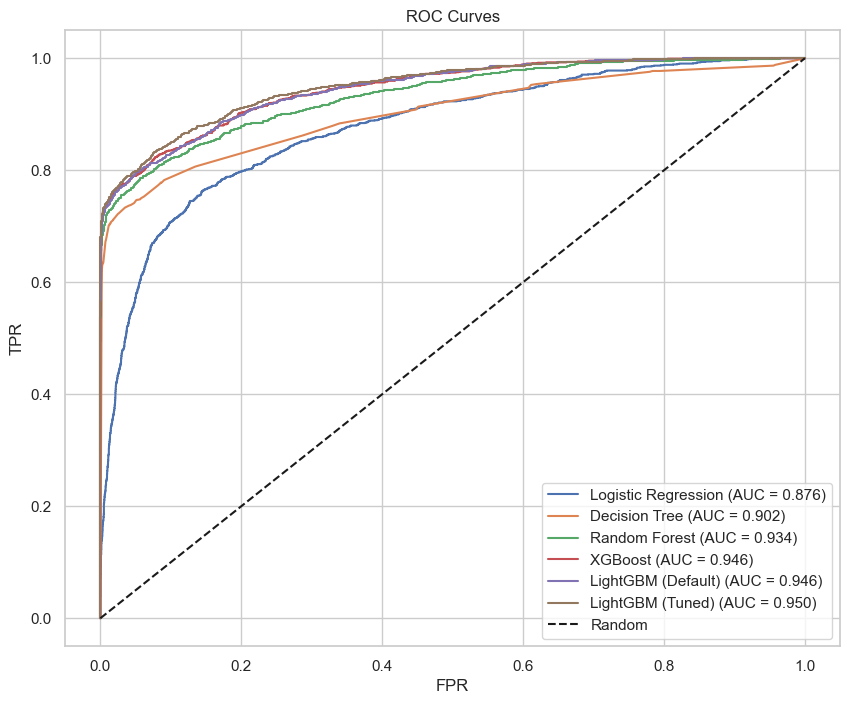

,Model,ROC-AUC,PR-AUC,F1-Score,Precision,Recall,KS-Statistic
0,Logistic Regression,0.876443,0.732326,0.641071,0.539850,0.789011,0.617596
1,Decision Tree,0.902084,0.852321,0.770975,0.796253,0.747253,0.698330
2,Random Forest,0.933753,0.884366,0.814964,0.903657,0.742125,0.727814
3,XGBoost,0.946035,0.899076,0.800296,0.809595,0.791209,0.744962
4,LightGBM (Default),0.945718,0.897884,0.803103,0.809985,0.796337,0.744451
5,LightGBM (Tuned),0.950177,0.906044,0.810287,0.824734,0.796337,0.754125


In [9]:
results_summary = []
plt.figure(figsize=(10, 8))

for name, model in models.items():
    probs = model.predict_proba(X_test_scaled)[:, 1]
    preds = model.predict(X_test_scaled)
    
    auc_roc = roc_auc_score(y_test, probs)
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probs)
    pr_auc = auc(recall_vals, precision_vals)
    f1 = f1_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    
    df_ks = pd.DataFrame({'y': y_test, 'prob': probs})
    ks_stats = []
    for thresh in np.linspace(0, 1, 100):
        t_neg = df_ks[df_ks['y'] == 0]['prob']
        t_pos = df_ks[df_ks['y'] == 1]['prob']
        neg_pct = (t_neg >= thresh).mean()
        pos_pct = (t_pos >= thresh).mean()
        ks_stats.append(abs(pos_pct - neg_pct))
    ks_stat = max(ks_stats)
    
    results_summary.append({
        'Model': name,
        'ROC-AUC': auc_roc,
        'PR-AUC': pr_auc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall': rec,
        'KS-Statistic': ks_stat
    })
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_roc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curves')
plt.legend()
plt.show()

results_df = pd.DataFrame(results_summary)
results_df

## Feature Interpretability (SHAP)

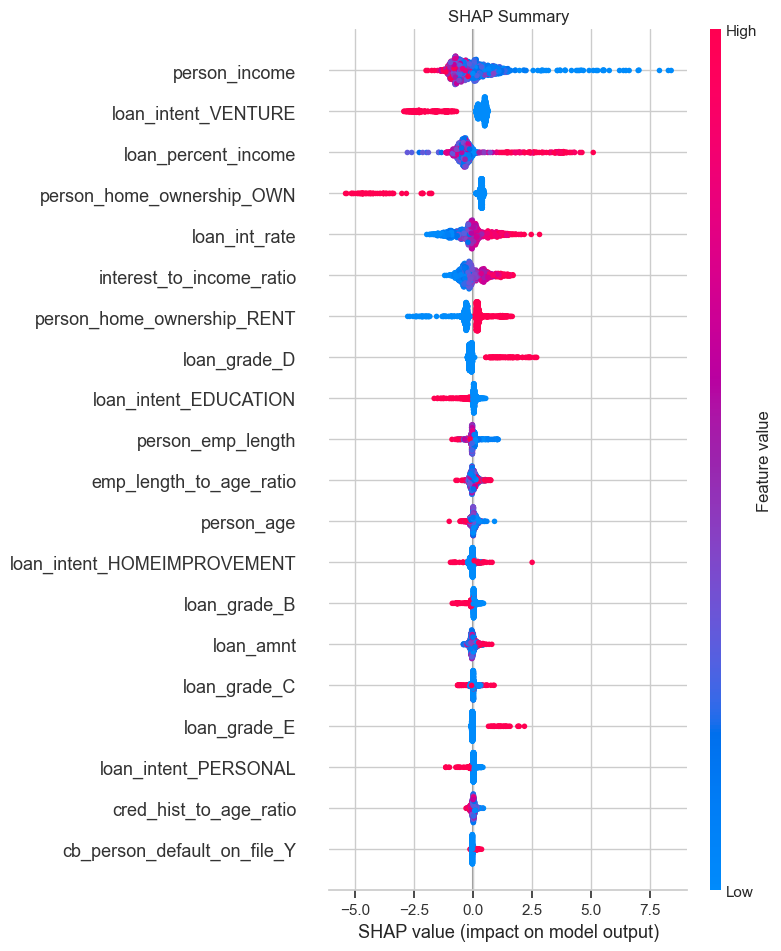

In [10]:
explainer = shap.TreeExplainer(best_lgb)
shap_sample = X_test_scaled.sample(1000, random_state=42)
shap_values = explainer(shap_sample)

shap.summary_plot(shap_values, shap_sample, show=False)
plt.title('SHAP Summary')
plt.show()

## Credit Score Band Analysis

C:\Users\itzjy\AppData\Local\Temp\ipykernel_13664\4144493280.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=band_analysis, x='score_band', y='default_rate_pct', palette='RdYlGn_r')


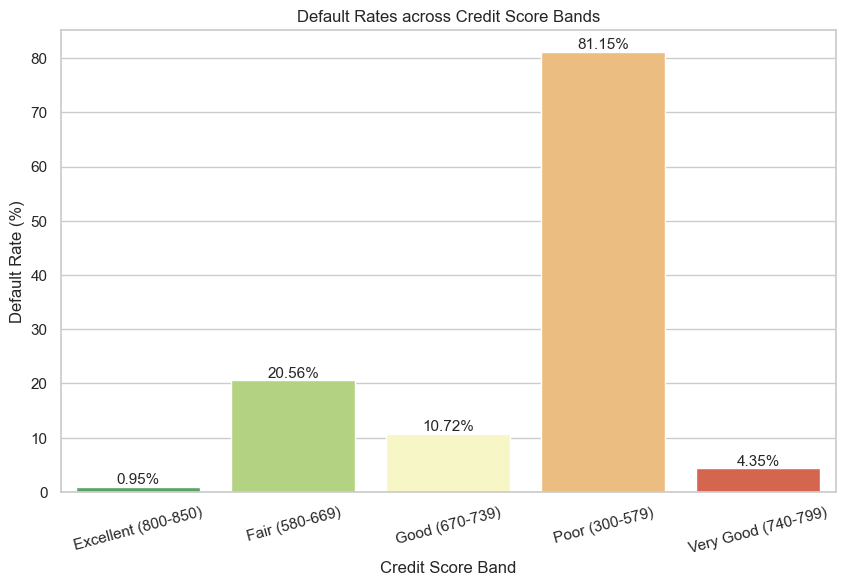

,score_band,total_accounts,defaults,default_rate,default_rate_pct
0,Excellent (800-850),2216,21,0.009477,0.947653
1,Fair (580-669),501,103,0.205589,20.558882
2,Good (670-739),830,89,0.107229,10.722892
3,Poor (300-579),1342,1089,0.811475,81.147541
4,Very Good (740-799),1447,63,0.043538,4.353836


In [11]:
test_probs = best_lgb.predict_proba(X_test_scaled)[:, 1]
test_scores = 850 - (test_probs * 550)

eval_df = pd.DataFrame({
    'loan_status': y_test,
    'default_prob': test_probs,
    'credit_score': test_scores
})

def get_score_band(score):
    if score >= 800: return 'Excellent (800-850)'
    elif score >= 740: return 'Very Good (740-799)'
    elif score >= 670: return 'Good (670-739)'
    elif score >= 580: return 'Fair (580-669)'
    else: return 'Poor (300-579)'

eval_df['score_band'] = eval_df['credit_score'].apply(get_score_band)
band_analysis = eval_df.groupby('score_band').agg(
    total_accounts=('loan_status', 'count'),
    defaults=('loan_status', 'sum'),
    default_rate=('loan_status', 'mean')
).reset_index()
band_analysis['default_rate_pct'] = band_analysis['default_rate'] * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=band_analysis, x='score_band', y='default_rate_pct', palette='RdYlGn_r')
plt.title('Default Rates across Credit Score Bands')
plt.xlabel('Credit Score Band')
plt.ylabel('Default Rate (%)')
plt.xticks(rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()
band_analysis